In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('gym_attendance.csv')
df

,ID,class_name,instructor,day,attendees,fee_usd
0,1,Yoga,Ms. Rania,Monday,18.0,50
1,2,yoga,Ms. Rania,Tuesday,22.0,50
2,3,Zumba,Mr. Tarek,Monday,30.0,-10
3,4,Pilates,Ms. Dina,Wednesday,NaN,45
4,5,ZUMBA,Mr. Tarek,Thursday,27.0,70
5,6,Spinning,Mr. Hany,Friday,350.0,60
6,7,Pilates,Ms. Dina,Friday,14.0,45
7,8,Zumba,Mr. Tarek,Monday,30.0,-10
8,9,Yoga,Ms. Rania,Saturday,20.0,50
9,10,boxing,Coach Amr,Sunday,25.0,80


In [2]:
# Fix 1 — Consistency: standardise class names to Title Case
df['class_name'] = df['class_name'].str.title()
df

,ID,class_name,instructor,day,attendees,fee_usd
0,1,Yoga,Ms. Rania,Monday,18.0,50
1,2,Yoga,Ms. Rania,Tuesday,22.0,50
2,3,Zumba,Mr. Tarek,Monday,30.0,-10
3,4,Pilates,Ms. Dina,Wednesday,NaN,45
4,5,Zumba,Mr. Tarek,Thursday,27.0,70
5,6,Spinning,Mr. Hany,Friday,350.0,60
6,7,Pilates,Ms. Dina,Friday,14.0,45
7,8,Zumba,Mr. Tarek,Monday,30.0,-10
8,9,Yoga,Ms. Rania,Saturday,20.0,50
9,10,Boxing,Coach Amr,Sunday,25.0,80


In [3]:
# Fix 2 — Accuracy: remove negative fees (logically impossible)
df = df[df['fee_usd'] >= 0]
df

,ID,class_name,instructor,day,attendees,fee_usd
0,1,Yoga,Ms. Rania,Monday,18.0,50
1,2,Yoga,Ms. Rania,Tuesday,22.0,50
3,4,Pilates,Ms. Dina,Wednesday,NaN,45
4,5,Zumba,Mr. Tarek,Thursday,27.0,70
5,6,Spinning,Mr. Hany,Friday,350.0,60
6,7,Pilates,Ms. Dina,Friday,14.0,45
8,9,Yoga,Ms. Rania,Saturday,20.0,50
9,10,Boxing,Coach Amr,Sunday,25.0,80
10,11,Boxing,Coach Amr,Monday,NaN,80
11,12,Cardio,Ms. Nour,Tuesday,40.0,55


In [4]:
# Fix 3 — Accuracy: remove outlier (350 attendees is unrealistic for a gym class)
df = df[df['attendees'] <= 100]
df

,ID,class_name,instructor,day,attendees,fee_usd
0,1,Yoga,Ms. Rania,Monday,18.0,50
1,2,Yoga,Ms. Rania,Tuesday,22.0,50
4,5,Zumba,Mr. Tarek,Thursday,27.0,70
6,7,Pilates,Ms. Dina,Friday,14.0,45
8,9,Yoga,Ms. Rania,Saturday,20.0,50
9,10,Boxing,Coach Amr,Sunday,25.0,80
11,12,Cardio,Ms. Nour,Tuesday,40.0,55
12,13,Cardio,Ms. Nour,Wednesday,38.0,55
14,15,Yoga,Ms. Rania,Friday,19.0,50
15,16,Pilates,Ms. Dina,Saturday,16.0,45


In [5]:
# Fix 4 — Completeness: fill missing attendees with mean of that class
for cls in df['class_name'].unique():
 mean_val = df[df['class_name'] == cls]['attendees'].mean()
 df.loc[(df['class_name'] == cls) & (df['attendees'].isna()),
'attendees'] = mean_val
df

,ID,class_name,instructor,day,attendees,fee_usd
0,1,Yoga,Ms. Rania,Monday,18.0,50
1,2,Yoga,Ms. Rania,Tuesday,22.0,50
4,5,Zumba,Mr. Tarek,Thursday,27.0,70
6,7,Pilates,Ms. Dina,Friday,14.0,45
8,9,Yoga,Ms. Rania,Saturday,20.0,50
9,10,Boxing,Coach Amr,Sunday,25.0,80
11,12,Cardio,Ms. Nour,Tuesday,40.0,55
12,13,Cardio,Ms. Nour,Wednesday,38.0,55
14,15,Yoga,Ms. Rania,Friday,19.0,50
15,16,Pilates,Ms. Dina,Saturday,16.0,45


In [6]:
# Fix 5 — Uniqueness: remove duplicate records
df = df.drop_duplicates()
df

,ID,class_name,instructor,day,attendees,fee_usd
0,1,Yoga,Ms. Rania,Monday,18.0,50
1,2,Yoga,Ms. Rania,Tuesday,22.0,50
4,5,Zumba,Mr. Tarek,Thursday,27.0,70
6,7,Pilates,Ms. Dina,Friday,14.0,45
8,9,Yoga,Ms. Rania,Saturday,20.0,50
9,10,Boxing,Coach Amr,Sunday,25.0,80
11,12,Cardio,Ms. Nour,Tuesday,40.0,55
12,13,Cardio,Ms. Nour,Wednesday,38.0,55
14,15,Yoga,Ms. Rania,Friday,19.0,50
15,16,Pilates,Ms. Dina,Saturday,16.0,45


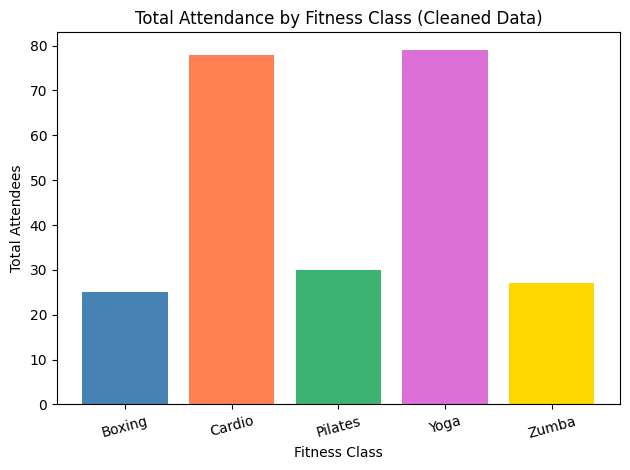

Clean dataset:
class_name  attendees
      Yoga       18.0
      Yoga       22.0
     Zumba       27.0
   Pilates       14.0
      Yoga       20.0
    Boxing       25.0
    Cardio       40.0
    Cardio       38.0
      Yoga       19.0
   Pilates       16.0
--- Clean Dataset Summary ---
class_name
Boxing     25.0
Cardio     78.0
Pilates    30.0
Yoga       79.0
Zumba      27.0


In [7]:
# --- BAR CHART ---
class_totals = df.groupby('class_name')['attendees'].sum()
plt.bar(class_totals.index, class_totals.values,

color=['steelblue','coral','mediumseagreen','orchid','gold','tomato'])
plt.title('Total Attendance by Fitness Class (Cleaned Data)')
plt.xlabel('Fitness Class')
plt.ylabel('Total Attendees')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print('Clean dataset:')
print(df[['class_name','attendees']].to_string(index=False))
print('--- Clean Dataset Summary ---')
print(class_totals.to_string())